
TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN
---Gradient Check---
 Relative Error: 0.00000007
Gradient is ✅

TEST 2: NUMPY vs PYTORCH
--- local PyTorch vs NumPy Check---
Max difference between NumPy and PyTorch outputs: 0.00000000
✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.

Statring Numpy Training
Epoch 01/15 | Train Loss: 1.7355
Epoch 02/15 | Train Loss: 1.6478
Epoch 03/15 | Train Loss: 1.5902
Epoch 04/15 | Train Loss: 1.5525
Epoch 05/15 | Train Loss: 1.5277
Epoch 06/15 | Train Loss: 1.5109
Epoch 07/15 | Train Loss: 1.4992
Epoch 08/15 | Train Loss: 1.4906
Epoch 09/15 | Train Loss: 1.4838
Epoch 10/15 | Train Loss: 1.4781
Epoch 11/15 | Train Loss: 1.4728
Epoch 12/15 | Train Loss: 1.4675
Epoch 13/15 | Train Loss: 1.4619
Epoch 14/15 | Train Loss: 1.4559
Epoch 15/15 | Train Loss: 1.4494
Numpy Total Training Time: 62.27 seconds

--- Evaluation Results for NumPy RNN ---
Accuracy: 46.69%
Macro-F1 Score: 0.1732

Per-Class F1 Scores:
  Walking: 0.6002
  Jogging: 0.4390
 

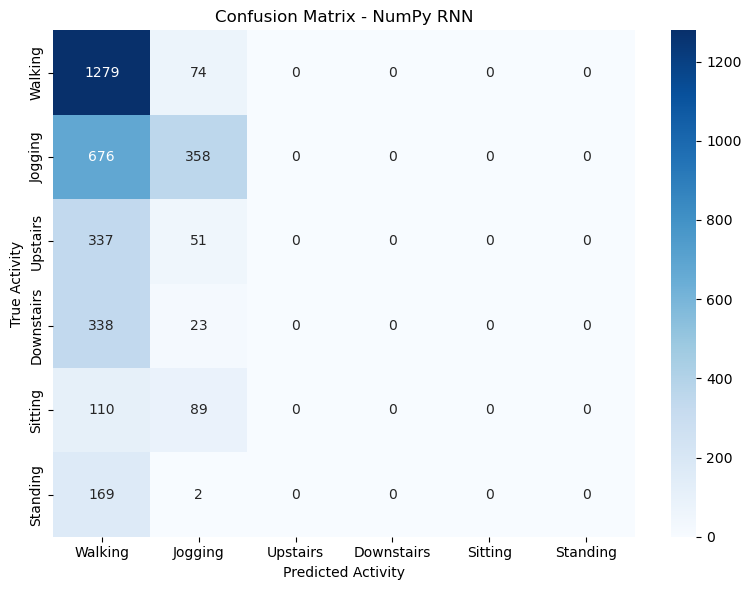


Statring PyTorch Training  PyTorch LSTM
Epoch 01/15 | Train Loss: 1.1991
Epoch 02/15 | Train Loss: 1.0110
Epoch 03/15 | Train Loss: 0.8084
Epoch 04/15 | Train Loss: 0.6980
Epoch 05/15 | Train Loss: 0.6519
Epoch 06/15 | Train Loss: 0.5721
Epoch 07/15 | Train Loss: 0.5136
Epoch 08/15 | Train Loss: 0.4544
Epoch 09/15 | Train Loss: 0.3922
Epoch 10/15 | Train Loss: 0.3433
Epoch 11/15 | Train Loss: 0.3320
Epoch 12/15 | Train Loss: 0.2878
Epoch 13/15 | Train Loss: 0.2693
Epoch 14/15 | Train Loss: 0.2272
Epoch 15/15 | Train Loss: 0.2337
PyTorch Total Training Time PyTorch LSTM: 26.64 seconds

--- Evaluation Results for PyTorch LSTM ---
Accuracy: 74.33%
Macro-F1 Score: 0.6846

Per-Class F1 Scores:
  Walking: 0.8385
  Jogging: 0.8408
  Upstairs: 0.4870
  Downstairs: 0.4517
  Sitting: 0.8753
  Standing: 0.6144


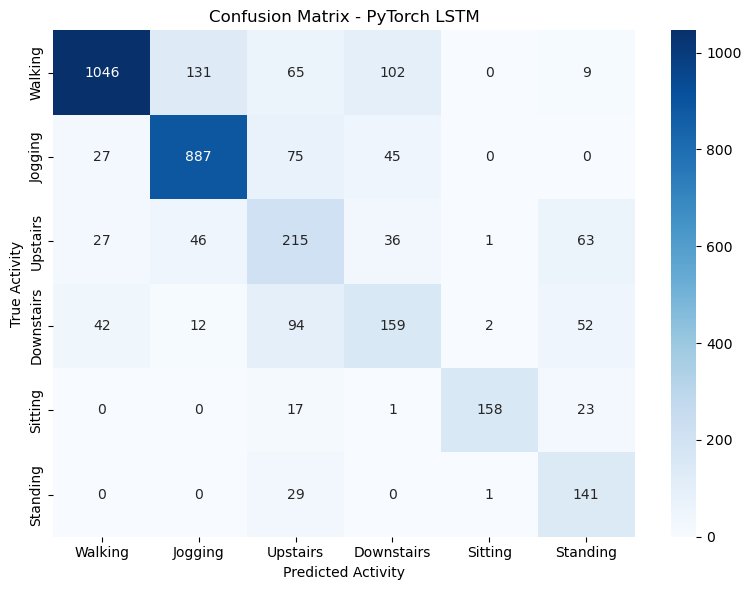


Statring PyTorch Training  PyTorch BiLSTM
Epoch 01/15 | Train Loss: 1.1487
Epoch 02/15 | Train Loss: 0.8581
Epoch 03/15 | Train Loss: 0.8155
Epoch 04/15 | Train Loss: 0.6984
Epoch 05/15 | Train Loss: 0.5812
Epoch 06/15 | Train Loss: 0.5732
Epoch 07/15 | Train Loss: 0.5260
Epoch 08/15 | Train Loss: 0.5004
Epoch 09/15 | Train Loss: 0.4379
Epoch 10/15 | Train Loss: 0.5188
Epoch 11/15 | Train Loss: 0.4046
Epoch 12/15 | Train Loss: 0.3214
Epoch 13/15 | Train Loss: 0.3062
Epoch 14/15 | Train Loss: 0.2797
Epoch 15/15 | Train Loss: 0.2600
PyTorch Total Training Time PyTorch BiLSTM: 51.26 seconds

--- Evaluation Results for PyTorch BiLSTM ---
Accuracy: 77.12%
Macro-F1 Score: 0.7014

Per-Class F1 Scores:
  Walking: 0.8820
  Jogging: 0.8528
  Upstairs: 0.5257
  Downstairs: 0.2750
  Sitting: 0.8531
  Standing: 0.8198


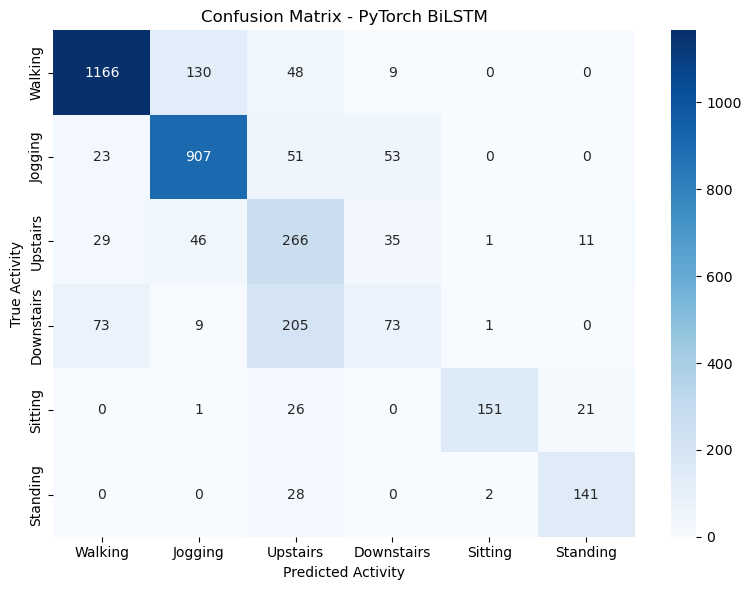


1. NumPy Simple RNN : Time = 62.27s | Accuracy = 46.69% | Macro-F1 = 0.1732
2. PyTorch LSTM     : Time = 26.64s | Accuracy = 74.33% | Macro-F1 = 0.6846
3. PyTorch BiLSTM   : Time = 51.26s | Accuracy = 77.12% | Macro-F1 = 0.7014


In [4]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from scipy import stats

np.random.seed(42)
try:
    FILE_PATH = Path(__file__).resolve().parent
except NameError:
    FILE_PATH = Path.cwd()

ACTIVITY_MAP = {
    "Walking": 0,
    "Jogging": 1,
    "Upstairs": 2,
    "Downstairs": 3,
    "Sitting": 4,
    "Standing": 5,
}
INT_TO_ACTIVITY = {v: k for k, v in ACTIVITY_MAP.items()}


def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


class NumPyRNN:

    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.lr = learning_rate
        self.hidden_dim = hidden_dim

        scale = 0.01
        self.Wxh = np.random.randn(input_dim, hidden_dim) * scale
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * scale
        self.Wyh = np.random.randn(hidden_dim, output_dim) * scale

        self.bh = np.zeros((1, hidden_dim))
        self.by = np.zeros((1, output_dim))

    def forward(self, X):
        batch_size, window_length, _ = X.shape

        hs = np.zeros((batch_size, window_length + 1, self.hidden_dim))

        for t in range(window_length):
            net_input = X[:, t, :] @ self.Wxh + hs[:, t - 1, :] @ self.Whh + self.bh
            hs[:, t, :] = np.tanh(net_input)

        last_hidden = hs[:, window_length - 1, :]
        logits = last_hidden @ self.Wyh + self.by
        probs = softmax(logits)

        cache = (X, hs, probs)
        return probs, cache

    @staticmethod
    def cross_entropy_loss(probs, y_true):
        epsilon = 1e-12
        n = probs.shape[0]
        correct_probs = probs[np.arange(n), y_true]
        loss = -np.mean(np.log(correct_probs + epsilon))
        return loss

    def backward(self, y_true, cache):
        X, hs, probs = cache
        batch_size, window_length, _ = X.shape

        dlogits = probs.copy()
        dlogits[np.arange(batch_size), y_true] -= 1
        dlogits /= batch_size

        last_hidden = hs[:, window_length - 1, :]
        dWyh = last_hidden.T @ dlogits
        dby = np.sum(dlogits, axis=0, keepdims=True)

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)

        dh_next = dlogits @ self.Wyh.T

        for t in reversed(range(window_length)):
            dtanh = (1 - hs[:, t, :] ** 2) * dh_next

            dWxh += X[:, t, :].T @ dtanh
            dWhh += hs[:, t - 1, :].T @ dtanh
            dbh += np.sum(dtanh, axis=0, keepdims=True)

            dh_next = dtanh @ self.Whh.T

        return {"dWxh": dWxh, "dWhh": dWhh, "dWyh": dWyh, "dbh": dbh, "dby": dby}

    def update_params(self, grads, max_grad_norm=5.0):
        for key in grads:
            grads[key] = np.clip(grads[key], -max_grad_norm, max_grad_norm)

        self.Wxh -= self.lr * grads["dWxh"]
        self.Whh -= self.lr * grads["dWhh"]
        self.Wyh -= self.lr * grads["dWyh"]
        self.bh -= self.lr * grads["dbh"]
        self.by -= self.lr * grads["dby"]


def create_windows(data, window_size=200, step_size=100):

    X_list = []
    Y_list = []

    for _, group in data.groupby("user"):
        features = group[["x", "y", "z"]].values
        activities = group["activity"].values

        for i in range(0, len(group) - window_size + 1, step_size):

            X_list.append(features[i : i + window_size])

            window_labels = activities[i : i + window_size]
            dominant_label = stats.mode(window_labels, keepdims=False)[0]
            Y_list.append(dominant_label)

    return np.array(X_list), np.array(Y_list)


def load_dataset():

    dataset_path = FILE_PATH / "dataset" / "WISDM_ar_v1.1_cleaned.csv"
    dataset = pd.read_csv(
        dataset_path,
        dtype={"user": int, "timestamp": float, "x": float, "y": float, "z": float},
    )
    # print("Dataset Type: " + str(type(dataset)))

    dataset["activity"] = dataset["activity"].map(ACTIVITY_MAP)

    # print("Dataset Head: " + str(dataset.head()))

    train_dataset = dataset[(dataset["user"]) <= 25].copy()
    test_dataset = dataset[dataset["user"] > 25].copy()

    train_features = train_dataset[["x", "y", "z"]].values
    test_features = test_dataset[["x", "y", "z"]].values

    # print("Train Features:\n" + str(train_features[0:10]))

    mean = np.mean(train_features, axis=0)
    std = np.std(train_features, axis=0) + 1e-8  # 1e-8 prevents division by zero

    train_dataset[["x", "y", "z"]] = (train_features - mean) / std

    test_dataset[["x", "y", "z"]] = (test_features - mean) / std

    return dataset, train_dataset, test_dataset


def check_gradient_numerical(model, X_sample, y_sample, epsilon=1e-7):
    print("---Gradient Check---")

    probs, cache = model.forward(X_sample)
    analytic_grads = model.backward(y_sample, cache)
    dWxh_analytic = analytic_grads["dWxh"]

    dWxh_num = np.zeros_like(model.Wxh)

    for i in range(model.Wxh.shape[0]):
        for j in range(model.Wxh.shape[1]):
            orig_val = model.Wxh[i, j]

            model.Wxh[i, j] = orig_val + epsilon
            probs_plus, _ = model.forward(X_sample)
            loss_plus = model.cross_entropy_loss(probs_plus, y_sample)

            model.Wxh[i, j] = orig_val - epsilon
            probs_minus, _ = model.forward(X_sample)
            loss_minus = model.cross_entropy_loss(probs_minus, y_sample)

            dWxh_num[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

            model.Wxh[i, j] = orig_val

    numerator = np.linalg.norm(dWxh_analytic - dWxh_num)
    denominator = np.linalg.norm(dWxh_analytic) + np.linalg.norm(dWxh_num) + 1e-12
    relative_error = numerator / denominator

    print(f" Relative Error: {relative_error:.8f}")
    if relative_error < 1e-5:
        print("Gradient is ✅")
    else:
        print("Gradient is ❌")


def local_Numpy_vs_nnRnn_check(
    numpy_model, input_dim, hidden_dim, batch_size=2, window_len=10
):
    print("--- local PyTorch vs NumPy Check---")

    pytorch_rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

    with torch.no_grad():
        pytorch_rnn.weight_ih_l0.copy_(torch.from_numpy(numpy_model.Wxh.T).float())
        pytorch_rnn.weight_hh_l0.copy_(torch.from_numpy(numpy_model.Whh.T).float())
        pytorch_rnn.bias_ih_l0.copy_(torch.from_numpy(numpy_model.bh.squeeze()).float())
        pytorch_rnn.bias_hh_l0.zero_()

    X_test_np = np.random.randn(batch_size, window_len, input_dim)
    X_test_torch = torch.from_numpy(X_test_np).float()

    _, cache = numpy_model.forward(X_test_np)
    out_numpy = cache[1][:, window_len - 1, :]

    out_torch, _ = pytorch_rnn(X_test_torch)
    out_torch_last = out_torch[:, -1, :].detach().numpy()

    diff = np.max(np.abs(out_numpy - out_torch_last))
    print(f"Max difference between NumPy and PyTorch outputs: {diff:.8f}")
    if diff < 1e-5:
        print("✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.")
    else:
        print("❌ Warning! Significant difference detected between outputs.")


class PyTorchSimpleRNN_Simple(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchBiLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


def evaluate_and_report(y_true, y_pred, model_name="Model"):

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"\n--- Evaluation Results for {model_name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1:.4f}")

    activity_names = [
        "Walking",
        "Jogging",
        "Upstairs",
        "Downstairs",
        "Sitting",
        "Standing",
    ]
    print("\nPer-Class F1 Scores:")
    for name, f1 in zip(activity_names, class_f1):
        print(f"  {name}: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=activity_names,
        yticklabels=activity_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Activity")
    plt.xlabel("Predicted Activity")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1, cm


def train_numpy_rnn(
    model, X_train, y_train, X_test, y_test, epochs=15, batch_size=64, max_grad_norm=5.0
):
    print("\n" + "=" * 60)
    print("Statring Numpy Training")
    print("=" * 60)

    start_time = time.time()
    num_samples = X_train.shape[0]

    for epoch in range(epochs):
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0.0
        num_batches = int(np.ceil(num_samples / batch_size))

        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            probs, cache = model.forward(X_batch)
            loss = model.cross_entropy_loss(probs, y_batch)
            epoch_loss += loss * (end_idx - start_idx)

            grads = model.backward(y_batch, cache)
            model.update_params(grads, max_grad_norm)

        epoch_loss /= num_samples
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"Numpy Total Training Time: {train_time:.2f} seconds")

    test_samples = X_test.shape[0]
    test_batches = int(np.ceil(test_samples / batch_size))
    y_pred_list = []

    for b in range(test_batches):
        start_idx = b * batch_size
        end_idx = min(start_idx + batch_size, test_samples)
        X_batch = X_test[start_idx:end_idx]
        probs, _ = model.forward(X_batch)
        y_pred_list.append(np.argmax(probs, axis=1))

    y_pred = np.concatenate(y_pred_list, axis=0)
    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, "NumPy RNN")
    return train_time, acc, macro_f1


def train_pytorch_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=15,
    batch_size=64,
    lr=0.005,
    model_name="PyTorch Model",
):
    print("\n" + "=" * 60)
    print(f"Statring PyTorch Training  {model_name}")
    print("=" * 60)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    X_test_tensor = torch.from_numpy(X_test).float()

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)

        epoch_loss /= len(train_dataset)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"PyTorch Total Training Time {model_name}: {train_time:.2f} seconds")

    model.eval()
    with torch.no_grad():
        test_outputs = []
        num_test = X_test_tensor.size(0)
        test_batches = int(np.ceil(num_test / batch_size))
        for b in range(test_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_test)
            out = model(X_test_tensor[start_idx:end_idx])
            test_outputs.append(torch.argmax(out, dim=1).numpy())

        y_pred = np.concatenate(test_outputs, axis=0)

    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, model_name)
    return train_time, acc, macro_f1


def main():
    dataset, train_dataset, test_dataset = load_dataset()

    X_train, y_train = create_windows(train_dataset)
    X_test, y_test = create_windows(test_dataset)
    # print("X_train shape:", X_train.shape)
    # print("y_train shape:", y_train.shape)

    input_dim = X_train.shape[2]
    hidden_dim = 32
    output_dim = 6
    learning_rate = 0.01

    numpy_model = NumPyRNN(
        input_dim, hidden_dim, output_dim, learning_rate=learning_rate
    )

    # TEST 1: Numerical Gradient Check (Section 2 Requirement)
    print("\n" + "=" * 60)
    print("TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN")
    print("=" * 60)
    check_gradient_numerical(numpy_model, X_train[:2], y_train[:2])

    # TEST 2: Sanity Check with PyTorch nn.RNN (Section 3 Requirement)
    print("\n" + "=" * 60)
    print("TEST 2: NUMPY vs PYTORCH")
    print("=" * 60)
    local_Numpy_vs_nnRnn_check(
        numpy_model, input_dim, hidden_dim, batch_size=2, window_len=X_train.shape[1]
    )

    # Pytorch training and testing
    numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
    time_np, acc_np, f1_np = train_numpy_rnn(
        numpy_model, X_train, y_train, X_test, y_test, epochs=15
    )

    # LSTM training and testing
    lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)
    time_lstm, acc_lstm, f1_lstm = train_pytorch_model(
        lstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch LSTM",
    )

    # BiLSTM training and testing
    bilstm_model = PyTorchBiLSTM(input_dim, hidden_dim, output_dim)
    time_bilstm, acc_bilstm, f1_bilstm = train_pytorch_model(
        bilstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch BiLSTM",
    )

    print("\n" + "=" * 70)
    print("=" * 70)
    print(
        f"1. NumPy Simple RNN : Time = {time_np:.2f}s | Accuracy = {acc_np*100:.2f}% | Macro-F1 = {f1_np:.4f}"
    )
    print(
        f"2. PyTorch LSTM     : Time = {time_lstm:.2f}s | Accuracy = {acc_lstm*100:.2f}% | Macro-F1 = {f1_lstm:.4f}"
    )
    print(
        f"3. PyTorch BiLSTM   : Time = {time_bilstm:.2f}s | Accuracy = {acc_bilstm*100:.2f}% | Macro-F1 = {f1_bilstm:.4f}"
    )
    print("=" * 70)


if __name__ == "__main__":
    main()